## Введение

Проект - House Prices - Advanced Regression Techniques.
Цель - построить модель ML для предсказания стоимости домов в Ames, Iowa, используя датасет  Ames Housing dataset. В проекте реализовано обучение RandomForest с подбором параметров с помощью GridSearch, бустинги XGBoost и CatBoost с подбором параметров с помощью Optuna.  
В силу условия проекта, будем работать с метрикой RMSE, рассчитанной на основе логарифма прогнозируемого значения и логарифма наблюдаемой цены продажи, будем называть ее RMSEL. 

In [43]:
# Подключаем нужные библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.metrics import root_mean_squared_error, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

In [13]:
# Загружаем данные
iowa_file_path = '/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv'
test_file_name = '/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv'

train = pd.read_csv(iowa_file_path)
y = train.SalePrice
test = pd.read_csv(test_file_name)

# Разделим признаки на числовые и категориальные 
numeric_cols = train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = train.select_dtypes(include=["object"]).columns

X = train.drop(columns=['SalePrice'])
y = train['SalePrice']

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# фунция ошибки
def rmsel(y_true, y_pred):
    return root_mean_squared_error(
        np.log(y_true),
        np.log(y_pred)
    )
    
rmsel_scorer = make_scorer(
    rmsel,
    greater_is_better=False
)

## Preprocessing

Сначала проверим data leakage. Подозрительные признаки: Id (не подозрительный, но явно лишний), SalePrice. Утечку через target уберем устранив подозрительные признаки. Утечку через preprocessing уберем с помощью pipeline. Удалим подозрительные.

### Missing values

Посмотрим в каких столбцах есть пропуски и сколько их. 

In [5]:
missing_df = pd.DataFrame({
    "dtype": train.dtypes,
    "count": train.isnull().sum(),
    "percent": train.isnull().mean() * 100
})

missing_df = missing_df[
    missing_df["count"] > 0
].sort_values("percent", ascending=False)

missing_df

,dtype,count,percent
PoolQC,object,1453,99.520548
MiscFeature,object,1406,96.301370
Alley,object,1369,93.767123
Fence,object,1179,80.753425
MasVnrType,object,872,59.726027
FireplaceQu,object,690,47.260274
LotFrontage,float64,259,17.739726
GarageType,object,81,5.547945
GarageYrBlt,float64,81,5.547945
GarageFinish,object,81,5.547945


Разберемся с пропущенными данными.  
Признаки из train_use, у которых >50% пропусков, впоследствии удалим. Пропусков в типе int64 нет.  
Пропуски LotFrontage заполняем средним. Признаки GarageType, GarageYrBlt, GarageFinish, GarageQual, GarageCond связаны и пропуски, видимо, означают отсутствие гаража. Поэтому выделим для пропусков отдельные значения: для GarageYrBlt - 0, для GarageType, GarageFinish, GarageQual, GarageCond - "None". В MasVnrArea заполним средним и добавим столбец True/False.  
Остались только категориальные переменные FireplaceQu, BsmtExposure, BsmtFinType2, BsmtQual, BsmtCond, BsmtFinType1, Electrical. FireplaceQu, BsmtExposure, BsmtFinType2, BsmtQual, BsmtCond, BsmtFinType1 - заполняем отдельным "None". Electrical - заполняем самым частым. 	


### Categorical values

Далее разберемся с категориальными переменными.  
Список тех, которые допускают упорядочивание: LotShape, LandSlope, ExterQual, ExterCond, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2, HeatingQC, KitchenQual, Functional, FireplaceQu, GarageFinish, GarageQual, GarageCond, PavedDrive, PoolQC, Fence. Эти признаки (точнее те из этого списка, которые не удалили ранее) закодируем с помощью Ordinal Encoding.
Для остальных: если >10 значений принимает - удаляем, иначе - OneHotEncoding.

### Pipeline

Для удобства и избежания некоторых ошибок создадим pipeline. Конвейер будет включать предварительную обработку train_use (в нашем случае: удаление признаков в >50% пропущенных значений, удаление подозрительных признаков, обработка остальных пропущенных значений, обработка категориальных переменных) и описание модели. 

### Processing number values

In [14]:
# Определяем числовые признаки
numerical_cols_use = train.select_dtypes(include='number').columns.tolist()

# Выделяем признаки в которых больше 50% пропусков
missing_ratio = train[numerical_cols_use].isna().mean()

drop_cols = missing_ratio[missing_ratio > 0.5].index.tolist()
# Лишние признаки
drop_cols += ['Id', 'SalePrice']

numerical_cols_use = [
    col for col in numerical_cols_use
    if col not in drop_cols
]

# LotFrontage -> среднее
lotfrontage_transformer = SimpleImputer(strategy='mean')

# GarageYrBlt -> 0
garageyrblt_transformer = SimpleImputer(strategy='constant', fill_value=0)

# MasVnrArea -> среднее + индикатор пропуска
masvnrarea_transformer = SimpleImputer(strategy='mean', add_indicator=True)

numerical_transformer = ColumnTransformer(
    transformers=[
        ('lotfrontage', lotfrontage_transformer, ['LotFrontage']),
        ('garageyrblt', garageyrblt_transformer, ['GarageYrBlt']),
        ('masvnrarea', masvnrarea_transformer, ['MasVnrArea'])
    ],
    remainder='passthrough'
)

### Processing categorical values 

In [15]:
# Определяем категориальные признаки
categorical_cols_use = train.select_dtypes(include='object').columns.tolist()

# Electrical → самое частое значение
electrical_imputer = SimpleImputer(strategy='most_frequent')

# Все остальные категориальные → "None"
categorical_imputer = SimpleImputer(
    strategy='constant',
    fill_value='None'
)

# Удаляем признаки, где >50% пропусков
missing_ratio = train[categorical_cols_use].isna().mean()

categorical_cols_use = [
    col for col in categorical_cols_use
    if missing_ratio[col] <= 0.5
]

# Признаки с упорядочиванием
ordinal_cols = ['LotShape','LandSlope','ExterQual','ExterCond','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','HeatingQC','KitchenQual','Functional','FireplaceQu','GarageFinish','GarageQual','GarageCond','PavedDrive','PoolQC','Fence']

# Оставляем только те, которые действительно есть после удаления
ordinal_cols = [
    col for col in ordinal_cols
    if col in categorical_cols_use
]

# Остальные категориальные
nominal_cols = [
    col for col in categorical_cols_use
    if col not in ordinal_cols
]

# Убираем Electrical из общего списка
nominal_cols = [
    col for col in nominal_cols
    if col != 'Electrical'
]

# Удаляем номинальные признаки >10 уникальных значений
nominal_cols = [
    col for col in nominal_cols
    if train[col].nunique(dropna=True) <= 5
]

# Шкалы для ordinal-признаков
# Одинаковая шкала для признаков качества
quality_cols = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC','KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']

quality_categories = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']

# Отдельные шкалы
ordinal_categories_dict = {
    col: quality_categories
    for col in quality_cols
}

ordinal_categories_dict.update({
    'LotShape': ['None', 'IR3', 'IR2', 'IR1', 'Reg'],

    'LandSlope': ['None', 'Sev', 'Mod', 'Gtl'],

    'BsmtExposure': ['None', 'No', 'Mn', 'Av', 'Gd'],

    'BsmtFinType1': [
        'None', 'Unf', 'LwQ', 'Rec',
        'BLQ', 'ALQ', 'GLQ'
    ],

    'BsmtFinType2': [
        'None', 'Unf', 'LwQ', 'Rec',
        'BLQ', 'ALQ', 'GLQ'
    ],

    'Functional': [
        'None', 'Sev', 'Maj2', 'Maj1',
        'Mod', 'Min2', 'Min1', 'Typ'
    ],

    'GarageFinish': ['None', 'Unf', 'RFn', 'Fin'],

    'PavedDrive': ['None', 'N', 'P', 'Y'],

    'Fence': ['None', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv']
})

# Оставляем категории только для тех ordinal-признаков, которые реально остались
ordinal_categories = [
    ordinal_categories_dict[col]
    for col in ordinal_cols
]

onehot_encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

# Ordinal-признаки
ordinal_transformer = Pipeline([
    ('imputer', categorical_imputer),
    ('encoder', OrdinalEncoder(
        categories=ordinal_categories,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

# Electrical
electrical_transformer = Pipeline([
    ('imputer', electrical_imputer),
    ('encoder', onehot_encoder)
])

# Остальные категориальные признаки
nominal_transformer = Pipeline([
    ('imputer', categorical_imputer),
    ('encoder', onehot_encoder)
])

# Объединяем всё
categorical_transformer = ColumnTransformer(
    transformers=[
        ('ordinal', ordinal_transformer, ordinal_cols),
        ('electrical', electrical_transformer, ['Electrical']),
        ('nominal', nominal_transformer, nominal_cols)
    ],
    remainder='drop'
)

In [16]:
# Общий preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols_use),
        ('cat', categorical_transformer, categorical_cols_use)
    ],
    remainder='drop'
)

## Random Forest

Рассмотрим как меняется ошибка при обучении случайного леса в зависимости от глубины деревьев.

In [17]:
depths = [5, 10, 15, 20, 25]
errors = []

for depth in depths:
    model_rf = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=100,
            max_depth=depth,
            random_state=1
        ))
    ])

    model_rf.fit(X_train, y_train)
    preds_rf = model_rf.predict(X_valid)

    rmsel_rf = rmsel(y_valid,preds_rf)

    errors.append(rmsel_rf)

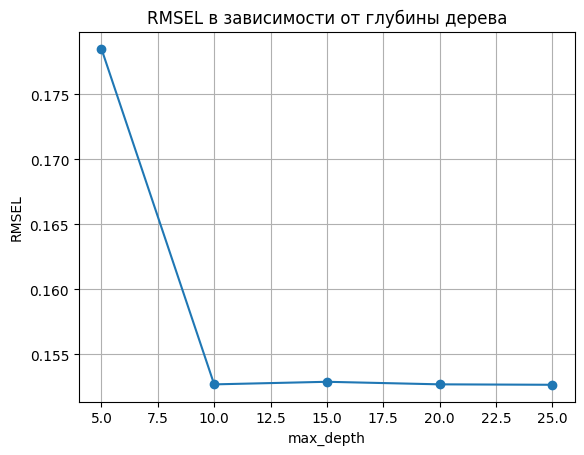

In [18]:
# Рисуем график
plt.plot(depths, errors, marker='o')
plt.xlabel('max_depth')
plt.ylabel('RMSEL')
plt.title('RMSEL в зависимости от глубины дерева')
plt.grid()
plt.show()

Как можно увидеть, график выходит на плато, поэтому можно использовать depth=12.

In [19]:
model_rf_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        random_state=1
    ))
])

model_rf_1.fit(X_train, y_train)

X_train_processed = model_rf_1.named_steps['preprocessor'].transform(X_train)

feature_names = (
    model_rf_1
    .named_steps['preprocessor']
    .get_feature_names_out()
)

rf_model = model_rf_1.named_steps['model']

In [20]:
# Вычисляем ошибку
preds_rf_1 = model_rf_1.predict(X_valid)

rmsel_rf_1 = rmsel(y_valid,preds_rf_1)

print(f'RMSEL: {rmsel_rf_1:.5f}')

RMSEL: 0.15218


### Cross-validation

In [21]:
model_rf_2 = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        random_state=1
    ))
])

# добавляем кросс-валидацию
scores = cross_val_score(
    model_rf_2,
    X,
    y,
    cv=5,
    scoring=rmsel_scorer
)

print('Scores:', -scores)
print(f'Mean RMSEL: {-scores.mean():.5f}')

Scores: [0.13702937 0.15255643 0.1440258  0.14022084 0.15566208]
Mean RMSEL: 0.14590


### GridSearch

In [14]:
# Улучшим модель с помощью подбора параметоров GridSearch
model_rf_3 = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        random_state=1
    ))
])

param_grid = {
    'model__n_estimators': [50, 100, 150],
    'model__max_depth': [10, 15, None],
    'model__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    model_rf_3,
    param_grid=param_grid,
    cv=5,
    scoring=rmsel_scorer,
    n_jobs=2
)

grid_search.fit(X, y)

print('Best parameters:', grid_search.best_params_)
print(f'Best RMSEL:, {-grid_search.best_score_:.5f}')

Best parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 150}
Best RMSEL:, 0.14537


## Gradient bossting

Обучим XGBoost с кросс-валидацией.

In [44]:
model_xgb_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=6,
        random_state=1
    ))
])

scores = cross_val_score(
    model_xgb_1,
    X,
    y,
    cv=5,
    scoring=rmsel_scorer,
    n_jobs=2
)

print('Scores:', -scores)
print(f'Mean RMSEL: {-scores.mean():.5f}')

Scores: [0.12391226 0.14926132 0.13435559 0.12338826 0.13772974]
Mean RMSEL: 0.13373


Сделаем подбор параметров с помощью Optuna.

In [48]:
def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)
    }

    model_xgb_2 = Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(
            **params,
            random_state=1
        ))
    ])

    scores = cross_val_score(
        model_xgb_2,
        X,
        y,
        cv=5,
        scoring=rmsel_scorer,
        n_jobs=2
    )

    return -scores.mean()

study = optuna.create_study(
    direction='minimize'
)

study.optimize(
    objective,
    n_trials=25
)

print('Best parameters:',study.best_params)
print(f'Best RMSEL: {study.best_value:.5f}')

[I 2026-10-06 08:35:33,482] A new study created in memory with name: no-name-003fda56-d851-42f4-b81d-9da415cf3326
[I 2026-10-06 08:35:39,134] Trial 0 finished with value: 0.12928280016463595 and parameters: {'n_estimators': 955, 'learning_rate': 0.016084948314238606, 'max_depth': 6, 'min_child_weight': 3, 'subsample': 0.6183509932624462, 'colsample_bytree': 0.8230286719259841, 'gamma': 0.47651782402159226, 'reg_alpha': 0.3791044289516578, 'reg_lambda': 0.21867291842284223}. Best is trial 0 with value: 0.12928280016463595.
[I 2026-10-06 08:35:40,525] Trial 1 finished with value: 0.13803546145446632 and parameters: {'n_estimators': 469, 'learning_rate': 0.017537093957454074, 'max_depth': 3, 'min_child_weight': 9, 'subsample': 0.8787935867967349, 'colsample_bytree': 0.847972064462988, 'gamma': 1.0935018712745048, 'reg_alpha': 2.0058371842412126, 'reg_lambda': 0.06822851103220556}. Best is trial 0 with value: 0.12928280016463595.
[I 2026-10-06 08:35:41,184] Trial 2 finished with value: 0.1

Best parameters: {'n_estimators': 773, 'learning_rate': 0.02497412579765297, 'max_depth': 4, 'min_child_weight': 1, 'subsample': 0.7078206298289514, 'colsample_bytree': 0.7658894574592562, 'gamma': 1.5153610075140258, 'reg_alpha': 0.10964247220848057, 'reg_lambda': 0.19173895453296377}
Best RMSEL: 0.12586


In [49]:
# Рисуем график подбора
optuna.visualization.plot_optimization_history(study)

## CatBoost

In [42]:
"""
# Обучим также CatBoost на наших данных
X_cv = X.copy()

cat_cols = X_cv.select_dtypes(include='object').columns.tolist()
X_cv[cat_cols] = X_cv[cat_cols].fillna('None')

y_cv = np.log(y)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def objective(trial):

    params = {
        'iterations': trial.suggest_int('iterations', 250, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10, log=True),
        'random_strength': trial.suggest_float('random_strength', 0, 2),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 5)
    }

    scores = []

    for train_idx, valid_idx in kf.split(X_cv):

        X_train_cv = X_cv.iloc[train_idx]
        X_valid_cv = X_cv.iloc[valid_idx]

        y_train_cv = y_cv.iloc[train_idx]
        y_valid_cv = y_cv.iloc[valid_idx]

        model = CatBoostRegressor(
            **params,
            loss_function='RMSE',
            random_seed=1,
            verbose=False,
            thread_count=2
        )

        model.fit(
            X_train_cv,
            y_train_cv,
            cat_features=cat_cols
        )

        preds_log = model.predict(X_valid_cv)

        score = root_mean_squared_error(
            y_valid_cv,
            preds_log
        )

        scores.append(score)

    return np.mean(scores)

study_cat = optuna.create_study(
    direction='minimize'
)

study_cat.optimize(
    objective,
    n_trials=5
)

print('Best parameters:', study_cat.best_params)
print(f'Best RMSEL: {study_cat.best_value:.5f}')
"""

[I 2026-10-06 08:12:00,119] A new study created in memory with name: no-name-12f84fc3-6936-4e07-a22a-303a3817b205
[I 2026-10-06 08:13:09,592] Trial 0 finished with value: 0.12784935361159813 and parameters: {'iterations': 970, 'learning_rate': 0.02737411974389739, 'depth': 5, 'l2_leaf_reg': 4.934863968301198, 'random_strength': 1.9554277511792557, 'bagging_temperature': 3.313013613363772}. Best is trial 0 with value: 0.12784935361159813.
[I 2026-10-06 08:13:37,289] Trial 1 finished with value: 0.13035459192022608 and parameters: {'iterations': 262, 'learning_rate': 0.058041529030151626, 'depth': 6, 'l2_leaf_reg': 1.7527552564798736, 'random_strength': 0.9414977919591832, 'bagging_temperature': 2.685016084587456}. Best is trial 0 with value: 0.12784935361159813.
[I 2026-10-06 08:16:13,059] Trial 2 finished with value: 0.12910537241419326 and parameters: {'iterations': 973, 'learning_rate': 0.022706083492339522, 'depth': 7, 'l2_leaf_reg': 3.8679810465409634, 'random_strength': 0.89882972

Best parameters: {'iterations': 687, 'learning_rate': 0.026766484073964734, 'depth': 6, 'l2_leaf_reg': 1.3260496465444702, 'random_strength': 1.436447529594749, 'bagging_temperature': 2.7738558477062973}
Best RMSEL: 0.12703


## Лучшая модель

Лучшей моделью оказался XGBoost с подбором параметров с помощью Optuna. Поэтому обучим модель на оптимальных параметрах и применим ее к тестовой выборке.

In [47]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        **study.best_params,
        random_state=1
    ))
])

model.fit(X, y)

test_preds = model.predict(test)

In [21]:
# Записываем результат применения модели в файл
output = pd.DataFrame({'Id': test.Id,
                      'SalePrice': test_preds})
output.to_csv('submission.csv', index=False)